In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
print(df.shape)

(1460, 81)


In [7]:
# Check Missing Values

missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
df.duplicated().sum()

0

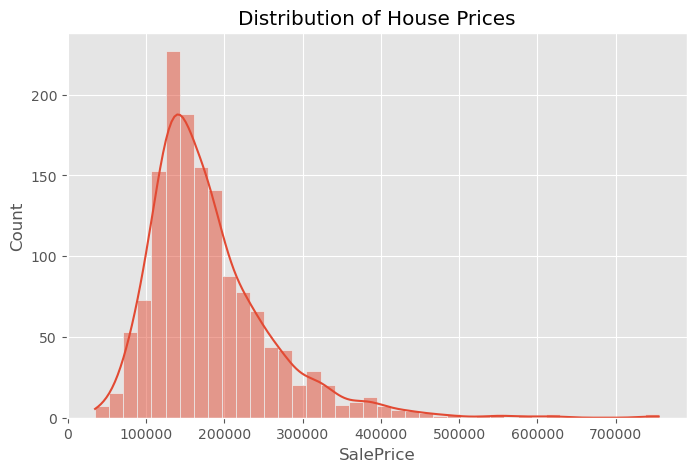

In [10]:
#  distribution of the target variable (price)

plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], bins=40, kde=True)
plt.title("Distribution of House Prices")

plt.show()

In [12]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [13]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21820\4074283006.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [14]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21820\1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [15]:
df.isnull().sum().sum()

0

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
corr = df.corr(numeric_only=True)
top_corr = corr["SalePrice"].sort_values(ascending=False)
top_corr.head(15)

SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
YearRemodAdd        0.507101
Foundation_PConc    0.497734
MasVnrArea          0.472614
Fireplaces          0.466929
GarageYrBlt         0.466754
Name: SalePrice, dtype: float64

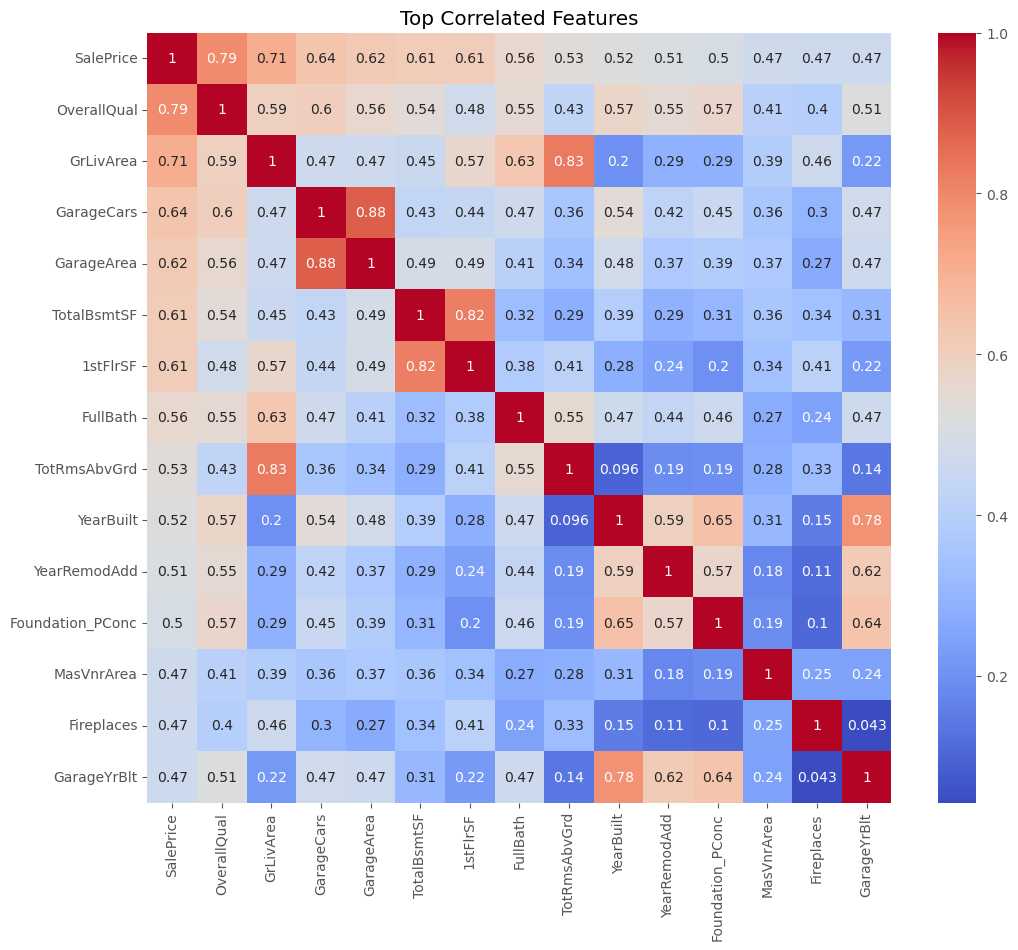

In [18]:
# Correlation heatmap

plt.figure(figsize=(12,10))
sns.heatmap(
    corr.loc[top_corr.index[:15], top_corr.index[:15]],
    annot=True,
    cmap="coolwarm"
)
plt.title("Top Correlated Features")
plt.show()

In [19]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [20]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [21]:
# Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = lr.predict(X_test)

In [23]:
#  Mean Squared Error (MSE)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2642483715.194208


In [24]:
# Root Mean Squared Error (RMSE)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 51405.094253334544


In [25]:
# R² score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.6554926552252509


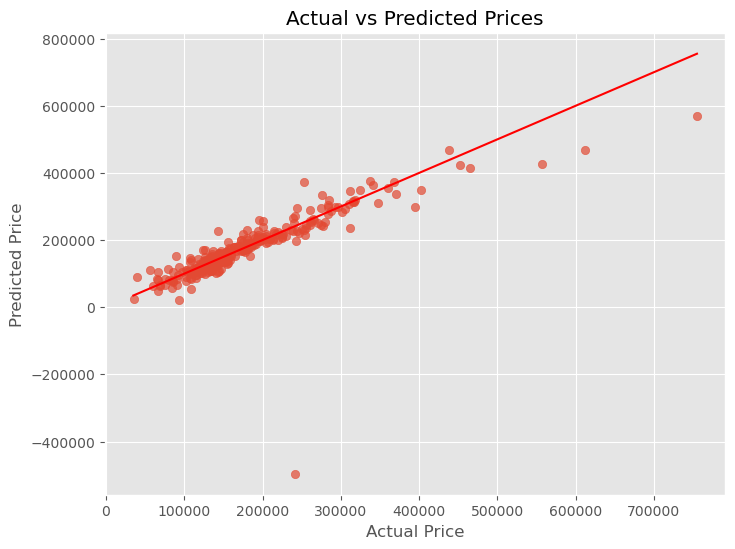

In [26]:
# actual prices vs. predicted prices

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

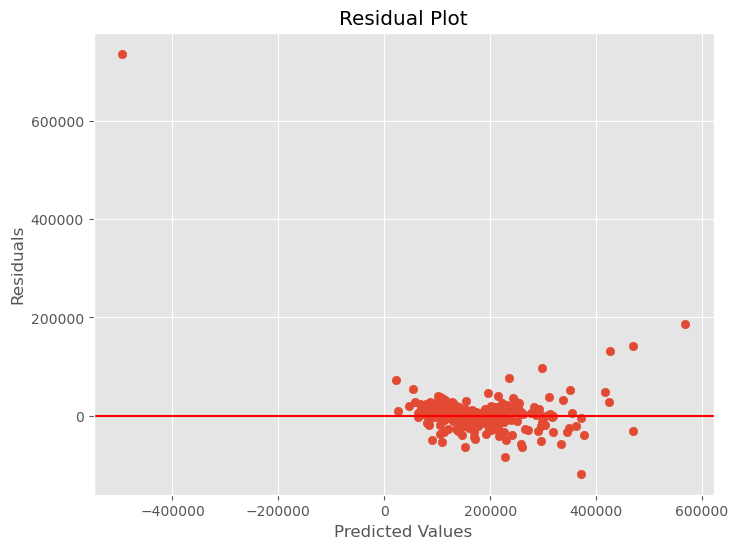

In [27]:
# Residual plot

residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [28]:
# Coefficient Analysis

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)
coefficients.head(15)

,Feature,Coefficient
113,RoofMatl_Metal,703938.743770
117,RoofMatl_WdShngl,669024.021699
115,RoofMatl_Tar&Grv,660213.976933
111,RoofMatl_CompShg,656684.748127
116,RoofMatl_WdShake,656003.506599
114,RoofMatl_Roll,655291.906954
221,GarageCond_TA,160379.807522
219,GarageCond_Gd,160335.375953
218,GarageCond_Fa,157287.365289
220,GarageCond_Po,154427.586467


In [29]:
coefficients.tail(15)

,Feature,Coefficient
98,BldgType_TwnhsE,-25424.802692
97,BldgType_Twnhs,-28357.379982
49,Utilities_NoSeWa,-33516.628283
183,Heating_OthW,-34329.840818
124,Exterior1st_ImStucc,-43116.257717
55,LandSlope_Sev,-45081.066465
201,Functional_Sev,-62612.874959
225,PoolQC_Gd,-74136.549054
224,PoolQC_Fa,-97048.051165
92,Condition2_RRAe,-97992.892258


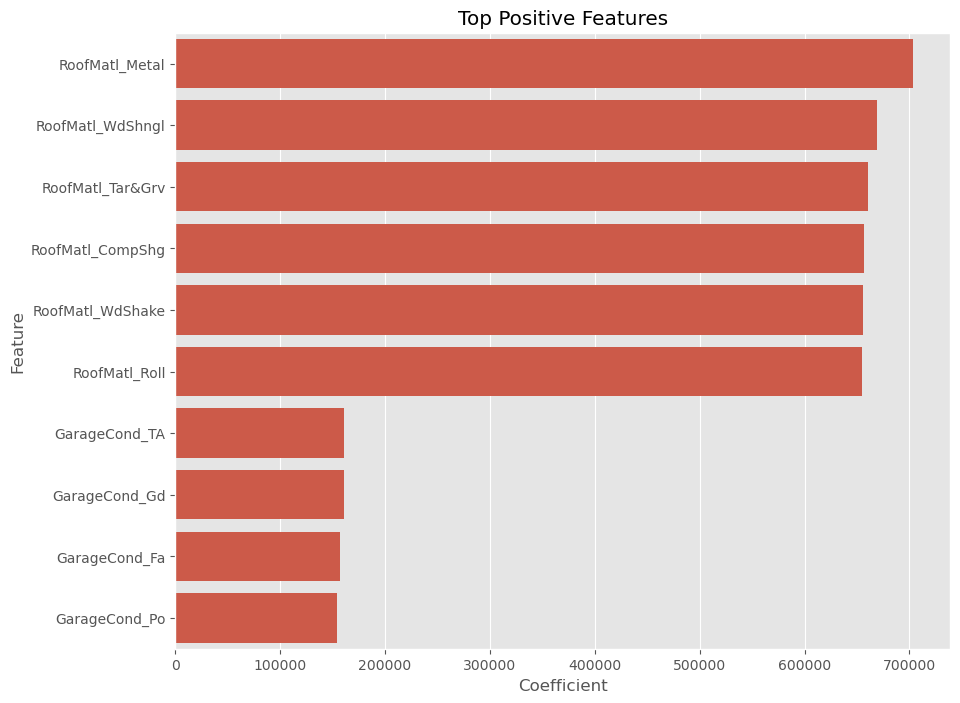

In [30]:
plt.figure(figsize=(10,8))
top = coefficients.head(10)
sns.barplot(
    data=top,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Positive Features")

plt.show()

In [31]:
# Bonus — Ridge Regression

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

In [32]:
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge RMSE: 30521.381156818734
Ridge R²: 0.8785508357067083


In [33]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Ridge"],
    "RMSE":[rmse,ridge_rmse],
    "R² Score":[r2,ridge_r2]
})
comparison

,Model,RMSE,R² Score
0,Linear Regression,51405.094253,0.655493
1,Ridge,30521.381157,0.878551
